In [1]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import glob

In [3]:
# set up constants
_SITE = "RGL"
_DATE = "202002"
_HEIGHT = "90magl"

## lat/lon zoomed in around RGL
slice_uk = {"lat": slice(40, 60), "lon": slice(-20, 10)}

In [51]:
from plotting_tools import load_fp, load_flux, load_obs

In [52]:
fps = load_fp(_SITE, _DATE, _HEIGHT)
obs = load_obs(_SITE, _DATE, _HEIGHT)
hourly_means = load_obs(_SITE, _DATE, _HEIGHT, mode="hourly")
fps.load()
obs.load()
hourly_means.load()

release_coords = {"lat":fps.isel(time=0).release_lat.values, "lon":fps.isel(time=0).release_lon.values}

In [10]:
time="2020-02-14T12:00:00"
time_idx = 100

In [31]:
## this controls wether the graphs are static or interactive!
%matplotlib widget

In [ ]:
from plotting_tools import plot_footprint, plot_timeseries, make_figure


In [18]:
time_idx= 100

2020-02-15T14:00:00


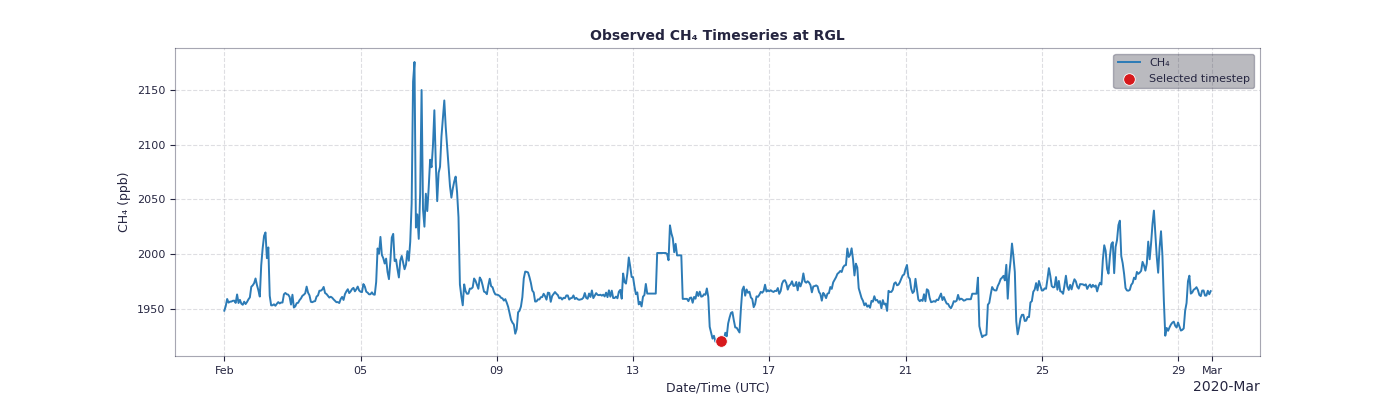

In [30]:
fig, ax = plt.subplots(figsize=(14, 4))
plot_timeseries(ax, hourly_means, time_idx="2020-02-15T14:00:00", site=_SITE) # , subset= ("2020-02-10", "2020-02-28")
#obs.ch4.plot(ax=ax, color="green", label="Observations", zorder=3)

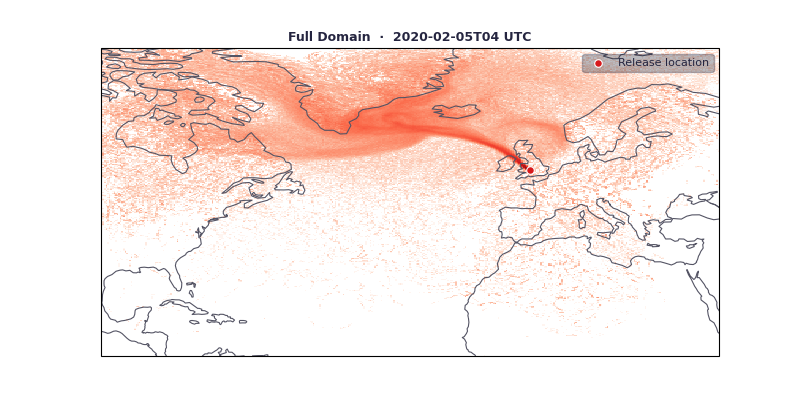

In [32]:
fig, ax = plt.subplots(figsize=(8, 4), subplot_kw={"projection": ccrs.PlateCarree()})
plot_footprint(ax, fps, hourly_means, time_idx, release_coords=release_coords, cmap="Reds")#, slice_dict=slice_uk)

2020-02-05T09:00:00.000000000


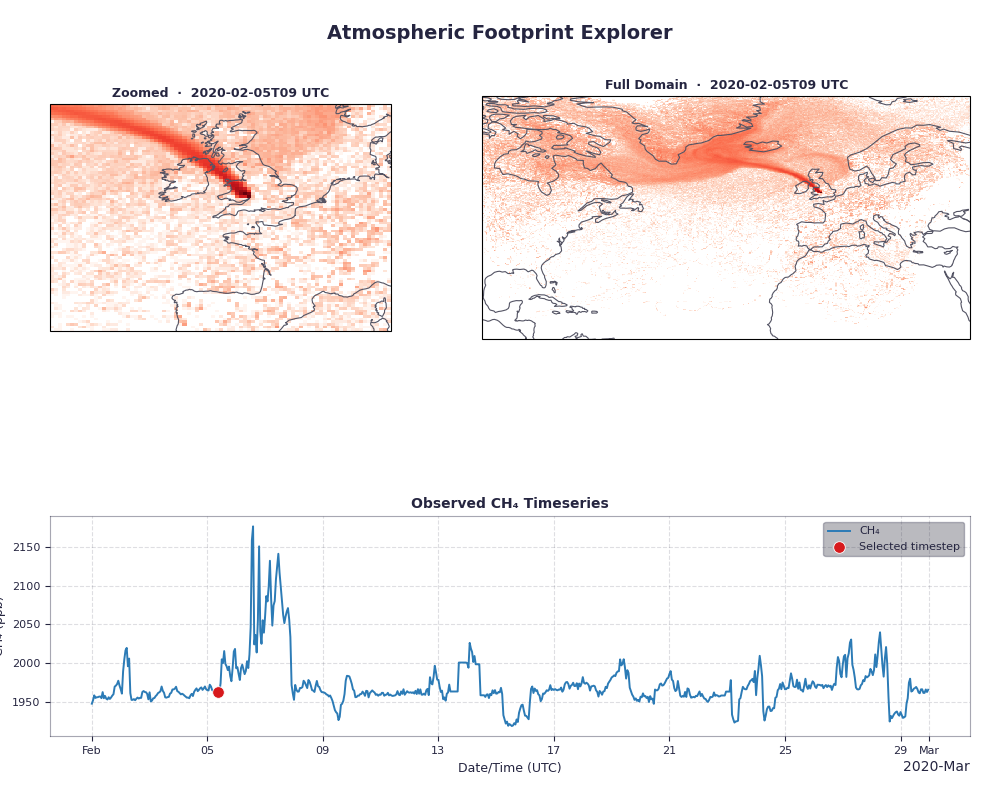

In [33]:
## MAKE STATIC FIGURE for a particular datapoint
fig, _ = make_figure(fps, hourly_means, slice_uk, time_idx=105, interactive=False)

2020-02-05T09:00:00.000000000


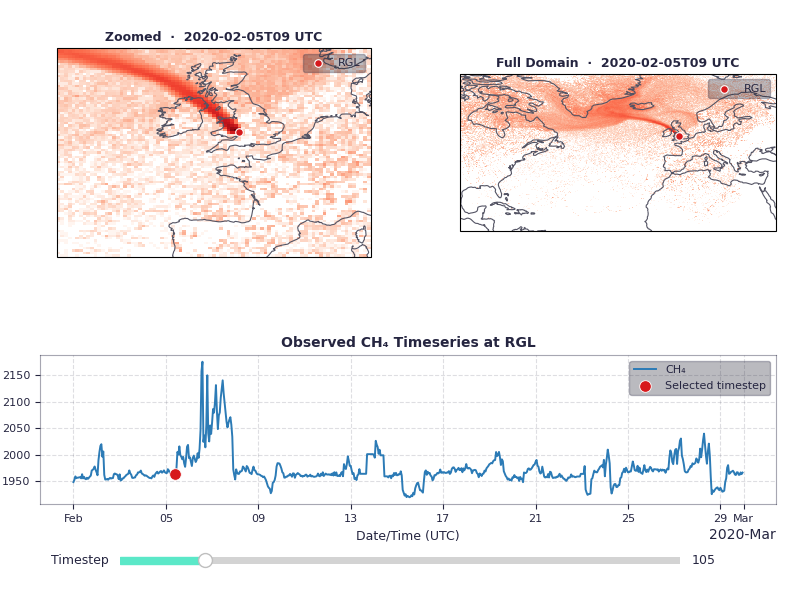

In [45]:
# MAKE INTERACTIVE FIGURE with slider
fig, slider = make_figure(
    fps, hourly_means, slice_uk,
    time_idx=105, interactive=True, figsize=(8,6), release_coords=release_coords, site=_SITE
)

In [47]:
load_flux("EUROPE", "2021")

<xarray.Dataset> Size: 461kB
Dimensions:  (lat: 293, lon: 391, time: 1)
Coordinates:
  * lat      (lat) float32 1kB 10.73 10.96 11.2 11.43 ... 78.59 78.82 79.06
  * lon      (lon) float32 2kB -97.9 -97.55 -97.2 -96.84 ... 38.68 39.03 39.38
  * time     (time) datetime64[ns] 8B 2021-01-01
Data variables:
    flux     (lat, lon, time) float32 458kB dask.array<chunksize=(293, 391, 1), meta=np.ndarray>
Attributes:
    Processed by:   cv18710@bristol.ac.uk
    Processed on:   2023-08-07 11:50:09.945746+00:00
    EDGAR sectors:  all
    EDGAR version:  v7
    EDGAR year:     2021

In [46]:
flux_path = "/group/chem/acrg/LPDM/emissions/EUROPE/ch4-edgar-annual-total_EUROPE_2021.nc"
flux = xr.open_dataset(flux_path)

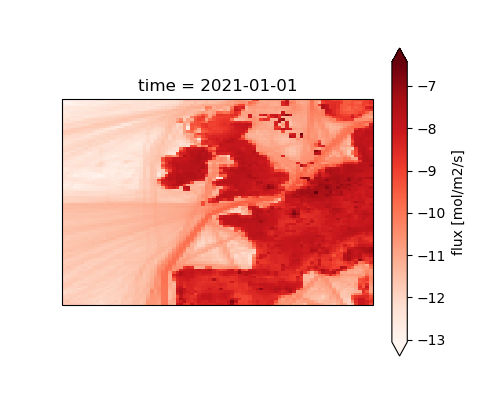

In [47]:
fig, ax = plt.subplots(figsize=(5,4), subplot_kw={"projection": ccrs.PlateCarree()})
np.log10(flux.sel(lat=slice_uk["lat"], lon=slice_uk["lon"]).flux.squeeze()).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="Reds" , extend="both"
    )
#ax.coastlines()